## Predicción de reinserción hospitalaria de pacientes con diabetes

# --------- Bibliotecas ----------

In [ ]:
# Link datos: http://bit.ly/1aZzTmO
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time ## Esta libreria será utilizada para ver el tiempo de ejecución del código
import pylab as pl
import corner as cn
import scipy

import hyperopt
from sklearn.naive_bayes import GaussianNB
from hyperopt import hp,fmin,tpe,STATUS_OK,Trials
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score,classification_report, confusion_matrix

# ---------- Funciones ----------

## > Binning / Bucketing

In [2]:
def binning(columna, data,N):
    frecuencias = data[columna].value_counts()
    
    # N valores más frecuentes
    top = frecuencias.nlargest(N).index
    
    # Reasignamos los valores que no están en el top como "otros"
    data[columna] = data[columna].apply(lambda x: x if x in top else 'otros')

## > Gráfico de barras (Frecuencia Variable&Readmisión)

In [3]:
def readmittedgrafico(columna, data):
    # Creamos una tabla cruzada que contabiliza la frecuencia total y la frecuencia de '1' en 'readmitted' para cada especialidad médica.
    frequency_table = pd.crosstab(data[columna], data['Reingresado'])
    frequency_table['Total'] = frequency_table.sum(axis=1)
    frequency_table['Readmitidos'] = frequency_table[1]

    # Graficamos las frecuencias
    ax = frequency_table[['Total', 'Readmitidos']].plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightgreen'])
    ax.set_title('Frecuencia Total y Readmisiones por columna de interés')
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')
    ax.set_xticklabels(frequency_table.index, rotation=45)
    plt.tight_layout()
    plt.show()

# ---------- Lectura de datos ----------

In [4]:
### Lectura de Documento  
data = pd.read_csv('diabetic_data.csv')
dataoriginal = data

### Reemplazar '?' por ''
data.replace('?', ' ', inplace=True)

# Verificar que columnas tienen valores faltantes
blancos = data.columns[data.isin([' ']).any()].tolist()

# Imprime las columnas con valores en blanco
print("Columnas con valores en blanco:", blancos)

Columnas con valores en blanco: ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']


# ---------- Cambio de nombre de columnas ----------

In [5]:
data.columns = ['ID de encuentro','ID Paciente', 'Raza', 'Género', 'Edad', 'Peso', 'Tipo de admisión', 'Destino',
                'Origen de admisión', 'Tiempo en hospital', 'Código pagador', 'Especialidad', 'N° Pruebas Lab', 
               'N° Pruebas', 'N° Medicamentos', 'N° Visitas ambulatorias', 'N° Visitas urgentes', 'N° Visitas hospitalarias',
               'Diagnóstico 1', 'Diagnóstico 2', 'Diagnóstico 3', 'N° Diagnósticos', 'Test glucosa', 'Test hemoglobina',
                'Metformina', 'Repaglinida', 'Nateglinida', 'Clorpropamida', 'Glimepirida', 'Acetohexamida', 'Glipizida', 
                'Glibenclamida', 'Tolbutamida', 'Pioglitazona', 'Rosiglitazona', 'Acarbosa', 'Miglitol', 'Troglitazona',
                'Tolazamida', 'Torasemida', 'Sitagliptina', 'Insulina', 'Gliburida y Metformina', 'Glipizina y Metformina',
                'Glimepirida y Pioglitazona', 'Metformina y Rosiglitazona', 'Metformina y Pioglitazina', 'Cambio',
                'Medicación diabetes prescrita', 'Reingresado']

# ---------- Data cleaning ----------

## > Eliminación de columnas

In [6]:
# >> Se elimina la columna "weight" por presentar un 97% de missing values. (Explicación en la presentación)
# >> Se elimina la columna "payer_code" por presentar un 52% de missing values y no importar mucho.
# >> Se elimina la columna "encounter_id" por no presentar ningún aporte al análisis.
# >> Se elimina la columna "examide" por no presentar ningún aporte al análisis. 
# >> Se elimina la columna "citoglipton" por no presentar ningún aporte al análisis.
# >> Se elimina la columna "metformin-pioglitazone" por no presentar ningún aporte al análisis.

data = data.drop(['Peso','Código pagador','ID de encuentro', 'Torasemida', 'Sitagliptina', 'Metformina y Pioglitazina'], axis=1)

# >> Se eliminan los duplicados de la columna 'patien_nbr' para quedarnos con el primer y único encuentro de un paciente.

data = data.drop_duplicates('ID Paciente')

# >> Se borra la columna porque no aporta más información

data = data.drop('ID Paciente', axis=1)

# >> Para la columna de 'discharge_disposition_id' se eliminan todos los encuentros con ID = 13, 14 (Hospice) e
# ID = 11, 19, 20, 21 (Fallecidos). Esto porque sesgan el estudio posterior.

eliminables_1 = [11, 13, 14, 19, 20, 21]
data = data[~data['Destino'].isin(eliminables_1)]

# >> Para la columna de 'gender' se eliminan todos los encuentros con gender desconocido (no aporta información).
data = data[data['Género'] != 'Unknown/Invalid']

# >> Luego de eliminar éstas columnas y filas previo análisis, se comprueba que no haya alguna columna que NO ENTREGUE INFORMACIÓN.
# Esto se traduce en que la suma de todos sus posibles valores únicos sea igual a 1.

for i in data.columns:
    if len(data[i].unique()) == 1:
        data = data.drop(i, axis=1)

## > Rellenar espacios en blanco y de letras a números

In [7]:
# Columna de especialidad médica
data['Especialidad'].replace(' ', 'missing', inplace=True)

# Columna de diagnóstico primario, secundario, terciario
dd = ['Diagnóstico 1', 'Diagnóstico 2', 'Diagnóstico 3']
for i in dd:
    data[i].replace(' ', '0', inplace=True)  
    # Se reemplazan los valores que no son números para su fácil manejo
    data[i] = data[i].str.replace('V', '10').str.replace('E', '100')
    
# Se cambia el tipo de dato a flotante
data[dd] = data[dd].astype('float64')

## > Descategorización de variables/columnas

In [8]:
# Descategorización edad
dvalag = dict(enumerate(data['Edad'].unique(), start=1))
for key in dvalag.keys():
    data['Edad'].replace(dvalag[key], key, inplace=True)

# Descategorización variable "max_glu_serum" (22)
dvalmgs = {'None':0, 'Norm':100, '>200':200, '>300':300}
data['Test glucosa']=data['Test glucosa'].map(dvalmgs)

# Descategorización variable "A1Cresult" (23)
dvalA1C = {'None':0, 'Norm':5, '>7':7, '>8':8}
data['Test hemoglobina']=data['Test hemoglobina'].map(dvalA1C)

# Descategorización variables "medicamentos" (24 - 46)
dvalmed = {'No':-20, 'Down':-10, 'Steady':0, 'Up':10}
for med in data.loc[:, 'Metformina':'Metformina y Rosiglitazona'].columns:
    data[med]=data[med].map(dvalmed)

# Descategorización variable "readmitted"
dvalread = {'NO':-1, '<30':1, '>30':1}
data['Reingresado']=data['Reingresado'].map(dvalread)

# Descategorización variable "diabetesMed"
dvaldm = {'No': -1, 'Yes':1}
data['Medicación diabetes prescrita']=data['Medicación diabetes prescrita'].map(dvaldm)

# Descategorización variable "change"
dvalch = {'No': -1, 'Ch':1}
data['Cambio']=data['Cambio'].map(dvalch)

# Descategorización variable "gender"
dvalgen = {'Female': -1, 'Male':1}
data['Género']=data['Género'].map(dvalgen)

# Descategorización raza
dvalraz = dict(enumerate(data['Raza'].unique(), start=1))
for key in dvalraz.keys():
    data['Raza'].replace(dvalraz[key], key, inplace=True)
    
# Descategorización Especialidad
dvalesp = dict(enumerate(data['Especialidad'].unique(), start=1))
for key in dvalesp.keys():
    data['Especialidad'].replace(dvalesp[key], key, inplace=True)

# Categorías icd_9 (para los diag_1, diag_2, diag_3)

### > Nombre de categorias: 
* Infectious and parasitic diseases
* Neoplasms
* Endocrine, nutritional and metabolic diseases, and immunity disorders
* Diseases of the blood and blood-forming organs
* Mental disorders
* Diseases of the nervous system and sense organs
* Diseases of the circulatory system
* Diseases of the respiratory system
* Diseases of the digestive system
* Diseases of the genitourinary system
* Complications of pregnancy, childbirth, and the puerperium
* Diseases of the skin and subcutaneous tissue
* Diseases of the musculoskeletal system and connective tissue
* Congenital anomalies
* Certain conditions originating in the perinatal period
* Symptoms, signs, and ill-defined conditions
* Injury and poisoning
* Otros (missing values y la categoría external causes of injury and supplemental classification)

In [9]:
icd9_categories = {
    '1-139': (1, 139),
    '140-239': (140, 239),
    '240-279': (240, 279),
    '280-289': (280, 289),
    '290-319': (290, 319),
    '320-389': (320, 389),
    '390-459': (390, 459),
    '460-519': (460, 519),
    '520-579': (520, 579),
    '580-629': (580, 629),
    '630-679': (630, 679),
    '680-709': (680, 709),
    '710-739': (710, 739),
    '740-759': (740, 759),
    '760-779': (760, 779),
    '780-799': (780, 799),
    '800-999': (800, 999),
    'Otros': (0, 0) 
}

# Creamos una nueva columna para asignar cada código a su categoría correspondiente
def assign_category(code):
    for category, (low, high) in icd9_categories.items():
        if low <= code <= high:
            return category
    return 'Otros'  # Códigos que son 0 o >= 1000 se asignan a 'otros'

aux=['Diagnóstico 1', 'Diagnóstico 2', 'Diagnóstico 3']
#aux2=['diag_1_encoded','diag_2_encoded','diag_3_encoded']
for i in range(3):
    #data[aux2[i]] = data[aux[i]].apply(assign_category)
    data[aux[i]] = data[aux[i]].apply(assign_category)

    # Ahora, creamos el histograma de las categorías ICD9
    #category_counts = data[aux2[i]].value_counts().reindex(icd9_categories.keys(), fill_value=0)
    category_counts = data[aux[i]].value_counts().reindex(icd9_categories.keys(), fill_value=0)
    #plt.figure(figsize=(12, 6))
   # category_counts.plot(kind='bar')
    #plt.title(aux[i])
   # plt.xlabel('Categoría ICD9')
   # plt.ylabel('Frecuencia')
   # plt.xticks(rotation=45)
   # plt.tight_layout()  # Ajustar para que las etiquetas no se corten
    #plt.show()

# Reducción de valores únicos

In [10]:
data['Edad'] = data['Edad'].apply(lambda x: 1 if x <= 3 else (2 if x <= 7 else 3))

binning('Raza',data,2)

binning('Destino',data,1)

binning('Diagnóstico 1', data, 8)

binning('Diagnóstico 2', data, 8)

binning('Diagnóstico 3', data, 8)

binning('Especialidad', data, 5)

# Reemplazo de la palabra "otros" en las variables que se ocupó biniing.
data['Destino'] = data['Destino'].replace('otros', 2)

# Reemplazo de la palabra "otros" en las variables que se ocupó biniing.
data['Raza'] = data['Raza'].replace('otros', -5)

# Reemplazo de la palabra "otros" en las variables que se ocupó biniing.
data['Especialidad'] = data['Especialidad'].replace('otros', 0)

# Descategorización Diagnósticos
dvaldiag1 = dict(enumerate(data['Diagnóstico 1'].unique(), start=1))
for key in dvaldiag1.keys():
    data['Diagnóstico 1'].replace(dvaldiag1[key], key, inplace=True)
                                  
dvaldiag2 = dict(enumerate(data['Diagnóstico 2'].unique(), start=1))
for key in dvaldiag2.keys():
    data['Diagnóstico 2'].replace(dvaldiag2[key], key, inplace=True)
                                  
dvaldiag3 = dict(enumerate(data['Diagnóstico 3'].unique(), start=1))
for key in dvaldiag3.keys():
    data['Diagnóstico 3'].replace(dvaldiag3[key], key, inplace=True)

# Eliminación de columnas estadísticamente no significativas

## ----- Variables categóricas

In [11]:
categoricas = ['Raza', 'Género', 'Tipo de admisión', 'Destino', 'Origen de admisión', 'Diagnóstico 1', 'Diagnóstico 2', 'Diagnóstico 3', 'Cambio', 'Medicación diabetes prescrita', 'Reingresado', 'Especialidad']
rechazadas = []
for cat in categoricas: 
    data_crosstab = pd.crosstab(data['Reingresado'], data[cat], margins = False) 
    stat, p, dof, expected = scipy.stats.chi2_contingency(data_crosstab)
    
    if p < 0.4 :
        print(round(p, 5), cat, 'es estadísticamente significativa')
    else:
        print(round(p, 5), cat, '---------------------no es estadísticamente significativa')
        rechazadas.append(cat)
data=data.drop(rechazadas,axis=1)

0.0 Raza es estadísticamente significativa
2e-05 Género es estadísticamente significativa
0.0 Tipo de admisión es estadísticamente significativa
0.0 Destino es estadísticamente significativa
0.0 Origen de admisión es estadísticamente significativa
0.0 Diagnóstico 1 es estadísticamente significativa
0.0 Diagnóstico 2 es estadísticamente significativa
0.0 Diagnóstico 3 es estadísticamente significativa
0.0 Cambio es estadísticamente significativa
0.0 Medicación diabetes prescrita es estadísticamente significativa
0.0 Reingresado es estadísticamente significativa
0.0 Especialidad es estadísticamente significativa


## ----- Variables numéricas

In [12]:
categoricas = ['Raza', 'Género', 'Tipo de admisión', 'Destino', 'Origen de admisión', 'Diagnóstico 1', 'Diagnóstico 2', 'Diagnóstico 3', 'Cambio', 'Medicación diabetes prescrita', 'Reingresado', 'Especialidad']
numericas = [elemento for elemento in list(data.columns) if elemento not in categoricas]
rechazadas2 = []
for cat in numericas: 
    rho , p = scipy.stats.spearmanr(data['Reingresado'], data[cat])
    if p < 0.4 :
        print(round(p, 5), cat, 'es estadísticamente significativa')
    else:
        print('--------------', round(p, 5), cat)
        rechazadas2.append(cat)
data=data.drop(rechazadas2,axis=1)

0.0 Edad es estadísticamente significativa
0.0 Tiempo en hospital es estadísticamente significativa
0.0 N° Pruebas Lab es estadísticamente significativa
0.0 N° Pruebas es estadísticamente significativa
0.0 N° Medicamentos es estadísticamente significativa
0.0 N° Visitas ambulatorias es estadísticamente significativa
0.0 N° Visitas urgentes es estadísticamente significativa
0.0 N° Visitas hospitalarias es estadísticamente significativa
0.0 N° Diagnósticos es estadísticamente significativa
0.0 Test glucosa es estadísticamente significativa
0.0 Test hemoglobina es estadísticamente significativa
0.0 Metformina es estadísticamente significativa
0.0 Repaglinida es estadísticamente significativa
0.23067 Nateglinida es estadísticamente significativa
-------------- 0.61467 Clorpropamida
0.37867 Glimepirida es estadísticamente significativa
0.2277 Acetohexamida es estadísticamente significativa
0.0 Glipizida es estadísticamente significativa
0.03843 Glibenclamida es estadísticamente significativ

# Modelo predictivo

In [13]:
X = data.loc[:,(data.columns != 'Reingresado')].values
print (X.shape)
y = data.loc[:, (data.columns == 'Reingresado')].values.flatten()
print (y.shape)

(69970, 37)
(69970,)


In [14]:
## Distribución de los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

print('Dimensiones de los datos de Entrenamiento: ' + str(X_train.shape) + ' ' +  str(y_train.shape))
print('Dimensiones de los datos de Prueba: ' + str(X_test.shape) + ' ' +  str(y_test.shape))

Dimensiones de los datos de Entrenamiento: (55976, 37) (55976,)
Dimensiones de los datos de Prueba: (13994, 37) (13994,)


In [15]:
# Normalizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Aplicar la misma escala al conjunto de prueba

 **Busqueda de Hiperparámetros utilizando Hyperopt**

In [23]:
space = {'criterion': hp.choice('criterion', ['entropy', 'gini']),
        'max_depth': hp.quniform('max_depth', 10, 1200, 10),
        'max_features': hp.choice('max_features', ['sqrt','log2']),
        'min_samples_leaf': hp.uniform('min_samples_leaf', 0, 0.5),
        'min_samples_split' : hp.uniform ('min_samples_split', 0, 1),
        'n_estimators' : hp.choice('n_estimators', [10, 50, 300, 750, 1200,1300,1500])
    }

def objective(space):
    model = RandomForestClassifier(criterion = space['criterion'], max_depth = int(space['max_depth']),
                                 max_features = space['max_features'],
                                 min_samples_leaf = space['min_samples_leaf'],
                                 min_samples_split = space['min_samples_split'],
                                 n_estimators = space['n_estimators'], 
                                 random_state=42,)
    
    f1 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1').mean()

    # Queremos maximizar el F1-score, por lo que se devuelve como valor negativo
    return {'loss': -f1, 'status': STATUS_OK}

In [ ]:
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100, trials=trials)
best

 51%|█████     | 51/100 [22:47<13:02, 15.98s/trial, best loss: -0.23249212276261763]  

In [28]:
best_params = {
    'criterion': ['entropy', 'gini'][best['criterion']],
    'max_depth': int(best['max_depth']),
    'max_features': ['sqrt', 'log2'][best['max_features']],
    'min_samples_leaf': best['min_samples_leaf'],
    'min_samples_split': best['min_samples_split'],
    'n_estimators': [10, 50, 300, 750, 1200, 1300, 1500][best['n_estimators']]
}

# Crear el modelo RandomForestClassifier con los mejores hiperparámetros
best_model = RandomForestClassifier(**best_params)

# Entrenar el modelo con tus datos de entrenamiento (X_train, y_train)
best_model.fit(X_train_scaled, y_train)

# Realizar predicciones en nuevos datos (suponiendo que tienes nuevos datos en X_new)
y_pred_rf= best_model.predict(X_test_scaled)

In [29]:
# Evaluación del modelo
print("exactitud: ", accuracy_score (y_test, y_pred_rf))
print( "precisión: ", precision_score (y_test, y_pred_rf, average = 'macro',zero_division=1))
print ("recall: ", recall_score (y_test, y_pred_rf, average = 'macro'))
print( "f1-score: ", f1_score (y_test, y_pred_rf, average = 'macro'))
cm = confusion_matrix (y_test, y_pred_rf) # columns: predicted, rows: true
print (cm)

exactitud:  0.6210518793768758
precisión:  0.6158409871023944
recall:  0.5474969177868232
f1-score:  0.503961318034578
[[7745  607]
 [4696  946]]


**Regresión Logística**

In [16]:
# 1. Regresión Logística
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train_scaled, y_train)

y_pred_lr=logistic_regression.predict(X_test_scaled)

# Evaluación del modelo
print("exactitud: ", accuracy_score (y_test, y_pred_lr))
print( "precisión: ", precision_score (y_test, y_pred_lr, average = 'macro',zero_division=1))
print ("recall: ", recall_score (y_test, y_pred_lr, average = 'macro'))
print( "f1-score: ", f1_score (y_test, y_pred_lr, average = 'macro'))
cm = confusion_matrix (y_test, y_pred_lr) # columns: predicted, rows: true
print (cm)


exactitud:  0.6228383592968415
precisión:  0.6049422823316084
recall:  0.5605243828443217
f1-score:  0.5371218579576881
[[7369  983]
 [4295 1347]]


**Naive Bayes Classifier**

In [18]:
gnb = GaussianNB()
y_pred_gnb = gnb.fit(X_train_scaled, y_train).predict(X_test_scaled)
# Evaluación del modelo
print("exactitud: ", accuracy_score (y_test, y_pred_gnb))
print( "precisión: ", precision_score (y_test, y_pred_gnb, average = 'macro',zero_division=1))
print ("recall: ", recall_score (y_test, y_pred_gnb, average = 'macro'))
print( "f1-score: ", f1_score (y_test, y_pred_gnb, average = 'macro'))
cm = confusion_matrix (y_test, y_pred_gnb) # columns: predicted, rows: true
print (cm)

exactitud:  0.6115478062026583
precisión:  0.5919429962547753
recall:  0.5374643818053162
f1-score:  0.4910112904448305
[[7684  668]
 [4768  874]]


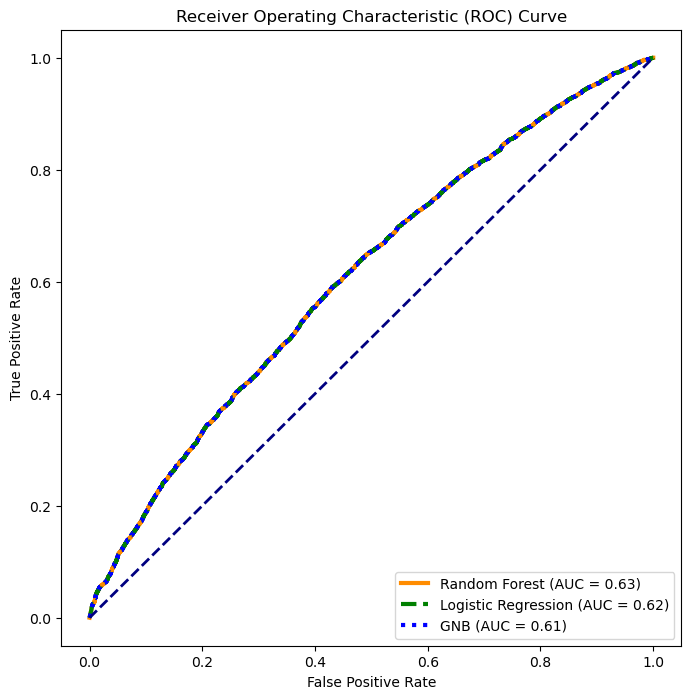

In [49]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener las predicciones de probabilidades del conjunto de prueba
y_pred_probaRF = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_probaLR = logistic_regression.predict_proba(X_test_scaled)[:, 1]
y_pred_probaNB = gnb.predict_proba(X_test_scaled)[:, 1]



# Calcular la tasa de falsos positivos y la tasa de verdaderos positivos
fpr1, tpr1, _ = roc_curve(y_test, y_pred_probaRF)
roc_auc1 = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(y_test, y_pred_probaLR)
roc_auc2 = auc(fpr2, tpr2)

fpr3, tpr3, _ = roc_curve(y_test, y_pred_probaNB)
roc_auc3 = auc(fpr3, tpr3)

# Graficar la curva ROC
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label='Random Forest (AUC = %0.2f)' % roc_auc1)
plt.plot(fpr, tpr, color='green', lw=3,linestyle='--', label='Logistic Regression (AUC = %0.2f)' % roc_auc2)
plt.plot(fpr, tpr, color='blue', lw=3,linestyle=':', label='GNB (AUC = %0.2f)' % roc_auc3)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

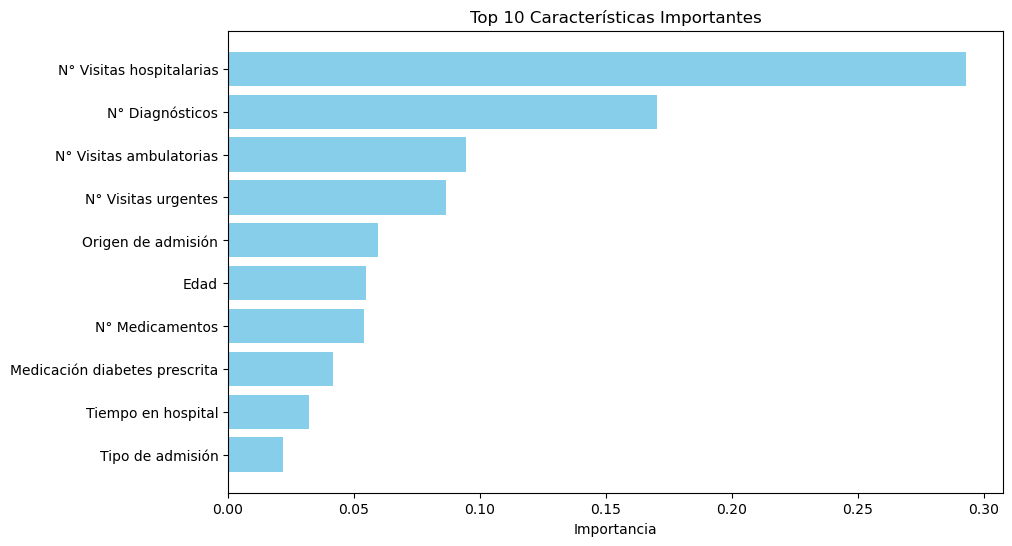

In [50]:
# Obtener la importancia de las características
feature_importance = best_model.feature_importances_

# Crear un DataFrame para visualizar las características junto con su importancia
feature_importance_df = pd.DataFrame({'Feature': data.columns[:len(data.columns)-1], 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualizar las características más importantes (por ejemplo, las 10 primeras)
top_features = feature_importance_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Importancia')
plt.title('Top 10 Características Importantes')
plt.gca().invert_yaxis()  # Invertir el eje y para mostrar la característica más importante en la parte superior
plt.show()